# 05b — Paper-style Visual Results Indonesia v4 — TOP4 + GEOS-STABLE

Perbaikan versi ini:

1. **Figure 5 sekarang menampilkan 4 tahun tertinggi:** **2003, 1997, 2015, 2004**. Setiap tahun memakai grid-event dengan severity tertinggi pada tahun itu.
2. **Figure 6 diperbaiki untuk Matplotlib baru:** `mpl.cm.get_cmap(...)` diganti dengan `mpl.colormaps["YlOrRd"].resampled(...)`.
3. Perbaikan GEOS dari v3 tetap dipertahankan: Cartopy Gridliner tidak digunakan; coastline/border tetap ada.
4. Logic ilmiah deteksi flash drought **tidak diubah**.

Disarankan: **Restart Kernel → Run All**.


In [1]:
from pathlib import Path
import json
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from scipy import stats

warnings.filterwarnings("once")

# ----------------------------
# Optional mapping libraries
# ----------------------------
HAS_CARTOPY = False
HAS_GPD = False

try:
    import cartopy
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
    HAS_CARTOPY = True
except Exception:
    cartopy = None
    HAS_CARTOPY = False

try:
    import geopandas as gpd
    HAS_GPD = True
except Exception:
    HAS_GPD = False

# ----------------------------
# USER PATHS
# ----------------------------
BASE = Path(r"D:\ERA5_LAND")

# Previous outputs
CLIM_DIR = BASE / "output_fd_03d_paper_climatology"
DRIVER_DIR = BASE / "output_fd_04b_robust_drivers_fast"
ONSET_DIR = BASE / "output_fd_03e_onset_sensitivity"
PERSIST_DIR = BASE / "output_fd_03f_persistence_sensitivity"
PCT_DIR = BASE / "output_fd_03g_percentile_sensitivity"

# Detection / percentile files for case-study figures
DETECTION_FILE = BASE / r"output_fd_03b_sensitivity\fd_detection_M2A_1995_2025_indonesia.nc"
PERCENTILE_FILE = BASE / r"output_rzsm\rzsm_percentile_gringorten_1995_2025.nc"

OUT = BASE / "output_fd_05b_paper_style_visuals"
OUT.mkdir(parents=True, exist_ok=True)

# ----------------------------
# Visual settings
# ----------------------------
FIG_DPI = 300
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.grid"] = False
plt.rcParams["font.size"] = 11

# Warm color palettes
CMAP_WARM = plt.get_cmap("YlOrRd")
CMAP_HOT = plt.get_cmap("OrRd")
CMAP_DEEP = plt.get_cmap("Reds")

# ----------------------------
# Analysis config
# ----------------------------
ANALYSIS_START = 1996
ANALYSIS_END = 2024
CASE_YEAR = 2003
ACTIVE_YEAR = 2003
ACTIVE_PENTAD = 29

# Four highest-ranked years from the current climatology result.
# Figure 5 shows one representative event for EACH year.
# Representative grid = event with the highest severity_p40_at_start
# within that year.
REP_YEARS = [2003, 1997, 2015, 2004]

# Indonesia subregion extents for selected-year map
SUBREGIONS = {
    "Kalimantan": [108.0, 119.0, -4.5, 4.5],
    "Sulawesi": [118.0, 126.5, -6.5, 2.0],
    "Maluku_NusaTenggara": [124.0, 136.0, -8.5, 2.0],
    "Papua": [130.0, 141.5, -10.5, 1.5],
}

# Indonesia main extent
INDO_EXTENT = [94.0, 142.0, -11.5, 7.0]

# ----------------------------
# File paths
# ----------------------------
CLIM_NC = CLIM_DIR / "fd_benchmark_climatology_metrics_1996_2024.nc"
HOTSPOT_NC = CLIM_DIR / "fd_benchmark_hotspot_masks.nc"
SEASON_CSV = CLIM_DIR / "seasonal_monthly_onset_contribution.csv"
ANNUAL_CSV = CLIM_DIR / "annual_spatial_metrics_1996_2024.csv"
EVENT_SUMMARY_CSV = CLIM_DIR / "benchmark_event_characteristics_summary.csv"

LAG_CSV = DRIVER_DIR / "year_block_onset_aligned_composite_bootstrap95.csv"
PHASE_CSV = DRIVER_DIR / "rapid_development_driver_states_bootstrap95.csv"

ONSET_SUMMARY_CSV = ONSET_DIR / "onset_4_vs_5_summary.csv"
ONSET_CONSIST_CSV = ONSET_DIR / "onset_4_vs_5_spatial_consistency.csv"

PERSIST_SUMMARY_CSV = PERSIST_DIR / "persistence_2_3_4_summary.csv"
PERSIST_CONSIST_CSV = PERSIST_DIR / "persistence_spatial_consistency.csv"

PCT_SUMMARY_CSV = PCT_DIR / "percentile_method_detection_summary.csv"
PCT_CONSIST_CSV = PCT_DIR / "percentile_method_detection_consistency.csv"

PCT_AGREE_CSV = PCT_DIR / "percentile_method_agreement.csv"

required = [
    CLIM_NC, HOTSPOT_NC, SEASON_CSV, ANNUAL_CSV, EVENT_SUMMARY_CSV,
    LAG_CSV, PHASE_CSV, DETECTION_FILE, PERCENTILE_FILE
]

print("Mapping support:")
print("  cartopy:", HAS_CARTOPY)
print("  geopandas:", HAS_GPD)

if HAS_CARTOPY:
    try:
        import shapely
        print("  cartopy version:", cartopy.__version__)
        print("  shapely version:", shapely.__version__)
    except Exception:
        pass

print(
    "\nGEOSTABLE mode: Cartopy Gridliner is DISABLED. "
    "Longitude/latitude labels use regular axis ticks instead."
)

print("\nRequired files:")
for p in required:
    print("  ", "OK" if p.exists() else "MISSING", p.name)


Mapping support:
  cartopy: True
  geopandas: True
  cartopy version: 0.25.0
  shapely version: 2.1.2

GEOSTABLE mode: Cartopy Gridliner is DISABLED. Longitude/latitude labels use regular axis ticks instead.

Required files:
   OK fd_benchmark_climatology_metrics_1996_2024.nc
   OK fd_benchmark_hotspot_masks.nc
   OK seasonal_monthly_onset_contribution.csv
   OK annual_spatial_metrics_1996_2024.csv
   OK benchmark_event_characteristics_summary.csv
   OK year_block_onset_aligned_composite_bootstrap95.csv
   OK rapid_development_driver_states_bootstrap95.csv
   OK fd_detection_M2A_1995_2025_indonesia.nc
   OK rzsm_percentile_gringorten_1995_2025.nc


## 1. Load results


In [2]:
clim = xr.open_dataset(CLIM_NC)
hot = xr.open_dataset(HOTSPOT_NC)
season = pd.read_csv(SEASON_CSV)
annual = pd.read_csv(ANNUAL_CSV)
event_summary = pd.read_csv(EVENT_SUMMARY_CSV)

lag = pd.read_csv(LAG_CSV)
phase = pd.read_csv(PHASE_CSV)

onset_summary = pd.read_csv(ONSET_SUMMARY_CSV) if ONSET_SUMMARY_CSV.exists() else None
onset_consist = pd.read_csv(ONSET_CONSIST_CSV) if ONSET_CONSIST_CSV.exists() else None

persist_summary = pd.read_csv(PERSIST_SUMMARY_CSV) if PERSIST_SUMMARY_CSV.exists() else None
persist_consist = pd.read_csv(PERSIST_CONSIST_CSV) if PERSIST_CONSIST_CSV.exists() else None

pct_summary = pd.read_csv(PCT_SUMMARY_CSV) if PCT_SUMMARY_CSV.exists() else None
pct_consist = pd.read_csv(PCT_CONSIST_CSV) if PCT_CONSIST_CSV.exists() else None
pct_agree = pd.read_csv(PCT_AGREE_CSV) if PCT_AGREE_CSV.exists() else None

det = xr.open_dataset(DETECTION_FILE, mask_and_scale=False)
pct = xr.open_dataset(PERCENTILE_FILE)["rzsm_percentile"]

display(event_summary)


<frozen importlib._bootstrap>:488: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject


,variable,unit,n_gridcell_events,mean,median,q25,q75
0,onset_speed_at_start,percentile points pentad-1,559676,32.961132,30.526993,19.280205,41.773781
1,onset_time_pentads_at_start,pentads,559676,1.720956,2.000000,1.000000,2.000000
2,duration_pentads_at_start,pentads,559676,7.648331,6.000000,5.000000,8.000000
3,below_p20_pentads_at_start,pentads,559676,5.927374,4.000000,3.000000,6.000000
4,severity_p40_at_start,percentile-point pentads,559676,195.640594,133.161957,101.388176,196.349609
5,minimum_percentile_at_start,percentile,559676,5.382042,5.012854,1.799486,8.226221


## 2. Helper functions for clearer paper-style visuals


In [3]:
def add_panel_label(ax, label):
    ax.text(
        0.01, 0.99, label,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=12, fontweight="bold",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.5)
    )

def add_note_box(ax, text, loc="upper left"):
    if loc == "upper left":
        x, y, ha, va = 0.02, 0.98, "left", "top"
    elif loc == "lower left":
        x, y, ha, va = 0.02, 0.02, "left", "bottom"
    elif loc == "upper right":
        x, y, ha, va = 0.98, 0.98, "right", "top"
    else:
        x, y, ha, va = 0.98, 0.02, "right", "bottom"

    ax.text(
        x, y, text,
        transform=ax.transAxes,
        ha=ha, va=va,
        fontsize=10,
        bbox=dict(facecolor="white", edgecolor="0.6", alpha=0.85, boxstyle="round,pad=0.3")
    )


def _nice_ticks(lo, hi, step_candidates=(1, 2, 5, 10)):
    """
    Return simple, human-readable ticks for a lon/lat interval.
    Designed for PlateCarree maps without Cartopy Gridliner.
    """
    span = float(hi - lo)

    if span <= 8:
        step = 2
    elif span <= 18:
        step = 5
    elif span <= 35:
        step = 5
    else:
        step = 10

    first = np.ceil(lo / step) * step
    last = np.floor(hi / step) * step

    if last < first:
        return np.array([(lo + hi) / 2.0])

    return np.arange(first, last + 0.1 * step, step)


def make_geo_ax(fig, position, extent=None):
    """
    GEOSTABLE map axis.

    Important:
    - Uses Cartopy PlateCarree for coastlines/borders.
    - DOES NOT call ax.gridlines(draw_labels=True).
    - Coordinates are labelled with normal x/y ticks instead.

    This avoids the Cartopy Gridliner -> Shapely/GEOS LinearRing
    failure that can occur during fig.savefig().
    """
    ext = extent if extent is not None else INDO_EXTENT

    if HAS_CARTOPY:
        ax = fig.add_subplot(
            position,
            projection=ccrs.PlateCarree(),
        )

        ax.set_extent(
            ext,
            crs=ccrs.PlateCarree(),
        )

        # Geographic outlines
        ax.coastlines(
            resolution="50m",
            linewidth=0.8,
            color="black",
            zorder=20,
        )

        ax.add_feature(
            cfeature.BORDERS.with_scale("50m"),
            linewidth=0.45,
            edgecolor="0.25",
            zorder=19,
        )

        # IMPORTANT: no Cartopy Gridliner here.
        xt = _nice_ticks(ext[0], ext[1])
        yt = _nice_ticks(ext[2], ext[3])

        ax.set_xticks(
            xt,
            crs=ccrs.PlateCarree(),
        )
        ax.set_yticks(
            yt,
            crs=ccrs.PlateCarree(),
        )

        ax.xaxis.set_major_formatter(
            LongitudeFormatter(
                degree_symbol="°",
                number_format=".0f",
            )
        )
        ax.yaxis.set_major_formatter(
            LatitudeFormatter(
                degree_symbol="°",
                number_format=".0f",
            )
        )

        ax.tick_params(
            labelsize=9,
            direction="out",
            length=3,
        )

        # Regular Matplotlib grid, not Cartopy Gridliner.
        ax.grid(
            True,
            linewidth=0.35,
            color="0.82",
            alpha=0.55,
            linestyle="--",
            zorder=1,
        )

        return ax

    # Fallback: plain Matplotlib axis
    ax = fig.add_subplot(position)
    ax.set_xlim(ext[0], ext[1])
    ax.set_ylim(ext[2], ext[3])
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_xticks(_nice_ticks(ext[0], ext[1]))
    ax.set_yticks(_nice_ticks(ext[2], ext[3]))
    ax.grid(
        True,
        linewidth=0.35,
        color="0.82",
        alpha=0.55,
        linestyle="--",
    )
    return ax


def pmesh_map(ax, da, cmap, title, cbar_label, vmin=None, vmax=None, discrete=None):
    if HAS_CARTOPY:
        x = da["longitude"].values
        y = da["latitude"].values
        data = da.values
        if discrete is None:
            im = ax.pcolormesh(
                x, y, data, cmap=cmap, shading="auto",
                vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree()
            )
        else:
            im = ax.pcolormesh(
                x, y, data, cmap=discrete["cmap"], norm=discrete["norm"], shading="auto",
                transform=ccrs.PlateCarree()
            )
    else:
        if discrete is None:
            im = ax.pcolormesh(
                da["longitude"], da["latitude"], da, cmap=cmap,
                shading="auto", vmin=vmin, vmax=vmax
            )
        else:
            im = ax.pcolormesh(
                da["longitude"], da["latitude"], da,
                cmap=discrete["cmap"], norm=discrete["norm"], shading="auto"
            )
    ax.set_title(title)
    return im



def safe_savefig(fig, path, dpi=300):
    """
    Save with a conservative Cartopy-friendly sequence.
    bbox_inches='tight' is tried first; if the backend raises a
    geometry-related rendering exception, save again without tight bbox.
    """
    path = Path(path)

    try:
        fig.savefig(
            path,
            dpi=dpi,
            bbox_inches="tight",
            facecolor="white",
        )
    except Exception as exc:
        msg = str(exc)
        if (
            "GEOSException" in type(exc).__name__
            or "LinearRing" in msg
            or "closed linestring" in msg
        ):
            print(
                "Geometry warning during tight save. "
                "Retrying without bbox_inches='tight'..."
            )
            fig.savefig(
                path,
                dpi=dpi,
                facecolor="white",
            )
        else:
            raise

def metric_phase(name):
    row = phase.loc[phase["metric"] == name].iloc[0]
    return float(row["mean"]), float(row["ci95_low"]), float(row["ci95_high"])

def metric_lag(var, lag_value):
    row = lag[(lag["variable"] == var) & (lag["lag"] == lag_value)].iloc[0]
    return row

def prepare_analysis_detection(ds):
    idx = np.flatnonzero(
        (np.asarray(ds["year"].values, dtype=int) >= ANALYSIS_START) &
        (np.asarray(ds["year"].values, dtype=int) <= ANALYSIS_END)
    )
    return ds.isel(time_index=idx)

def auto_select_representative_event(det_ds, year_choice):
    d = det_ds.where(det_ds["year"] == year_choice, drop=True)
    sev = d["severity_p40_at_start"].where(d["fd_event_start"] == 1)

    df = sev.to_dataframe(name="severity").dropna().reset_index()
    if len(df) == 0:
        raise ValueError(f"No event found for year {year_choice}.")
    row = df.loc[df["severity"].idxmax()]
    return {
        "time_index": int(row["time_index"]),
        "latitude": float(row["latitude"]),
        "longitude": float(row["longitude"]),
        "severity": float(row["severity"]),
        "pentad": int(row["pentad"]),
        "year": int(row["year"]),
    }

def build_full_time_labels(det_ds):
    years = np.asarray(det_ds["year"].values, dtype=int)
    pentads = np.asarray(det_ds["pentad"].values, dtype=int)
    return [f"{y}-P{p:02d}" for y, p in zip(years, pentads)]


# Figure 1 — Main climatology overview
Warna dibuat **lebih hangat** dan peta diberi **garis pantai / batas negara** jika `cartopy` tersedia.


c:\Users\User\anaconda3\envs\era5\Lib\site-packages\cartopy\mpl\ticker.py:151: MatplotlibDeprecationWarning: The locs attribute was deprecated in Matplotlib 3.11 and will be removed in 3.13.
  self.locs, degs, mins, secs = self._get_dms(self.locs)
c:\Users\User\anaconda3\envs\era5\Lib\site-packages\cartopy\mpl\ticker.py:151: MatplotlibDeprecationWarning: The locs attribute was deprecated in Matplotlib 3.11 and will be removed in 3.13.
  self.locs, degs, mins, secs = self._get_dms(self.locs)
c:\Users\User\anaconda3\envs\era5\Lib\site-packages\cartopy\mpl\ticker.py:151: MatplotlibDeprecationWarning: The locs attribute was deprecated in Matplotlib 3.11 and will be removed in 3.13.
  self.locs, degs, mins, secs = self._get_dms(self.locs)
c:\Users\User\anaconda3\envs\era5\Lib\site-packages\cartopy\mpl\ticker.py:151: MatplotlibDeprecationWarning: The locs attribute was deprecated in Matplotlib 3.11 and will be removed in 3.13.
  self.locs, degs, mins, secs = self._get_dms(self.locs)
c:\Users

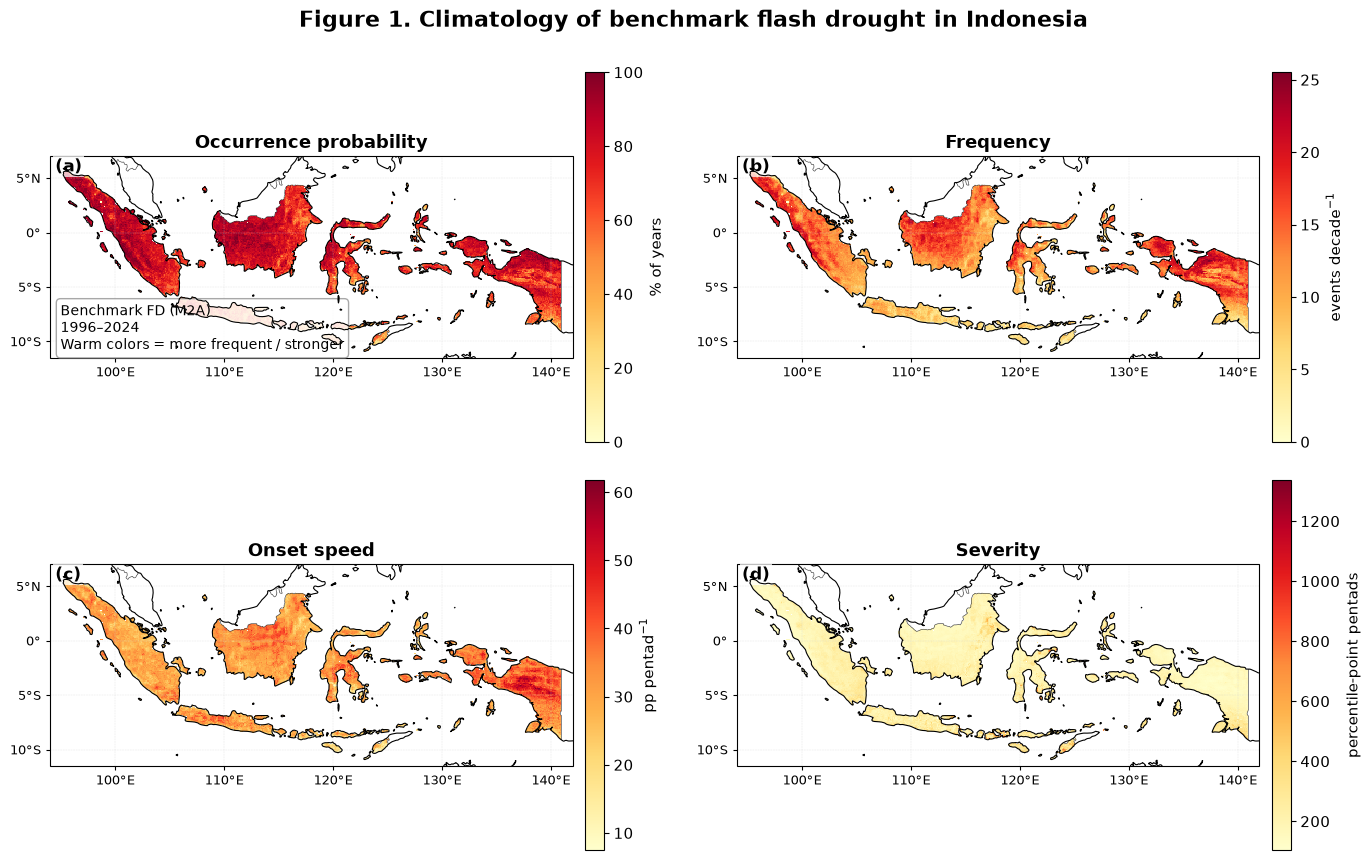

In [4]:
fig = plt.figure(figsize=(14, 9))

items = [
    ("occurrence_probability_percent", "Occurrence probability", "% of years", "a"),
    ("events_per_decade", "Frequency", "events decade$^{-1}$", "b"),
    ("mean_onset_speed_pp_per_pentad", "Onset speed", "pp pentad$^{-1}$", "c"),
    ("mean_severity_p40_pp_pentad", "Severity", "percentile-point pentads", "d"),
]

positions = [221, 222, 223, 224]

for pos, (var, ttl, cbar, lab) in zip(positions, items):
    ax = make_geo_ax(fig, pos, INDO_EXTENT)
    da = clim[var]
    im = pmesh_map(ax, da, CMAP_WARM, ttl, cbar)
    cb = fig.colorbar(im, ax=ax, pad=0.02, shrink=0.88)
    cb.set_label(cbar)
    add_panel_label(ax, f"({lab})")

add_note_box(
    fig.axes[0],
    "Benchmark FD (M2A)\n1996–2024\nWarm colors = more frequent / stronger",
    loc="lower left",
)

fig.suptitle("Figure 1. Climatology of benchmark flash drought in Indonesia", fontsize=16, fontweight="bold")
fig.tight_layout()
safe_savefig(fig, OUT / "Figure1_climatology_overview_warm.png", dpi=FIG_DPI)
plt.show()


# Figure 2 — Seasonality and interannual variability


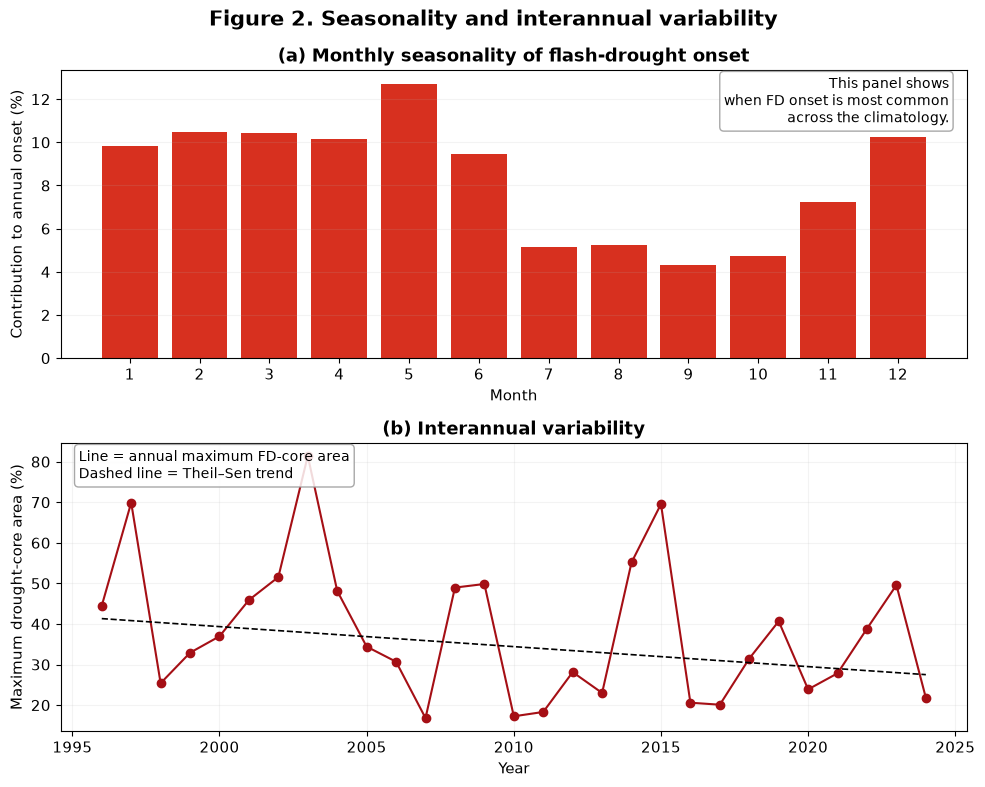

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

axes[0].bar(season["month"], season["contribution_percent"], color="#d7301f")
axes[0].set_xticks(range(1, 13))
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Contribution to annual onset (%)")
axes[0].set_title("(a) Monthly seasonality of flash-drought onset")
axes[0].grid(axis="y", alpha=0.15)
add_note_box(
    axes[0],
    "This panel shows\nwhen FD onset is most common\nacross the climatology.",
    loc="upper right"
)

axes[1].plot(
    annual["year"], annual["maximum_drought_core_area_percent"],
    color="#a50f15", marker="o", linewidth=1.5
)
x = np.asarray(annual["year"], dtype=float)
y = np.asarray(annual["maximum_drought_core_area_percent"], dtype=float)
ok = np.isfinite(x) & np.isfinite(y)
if ok.sum() >= 3:
    slope, intercept, _, _ = stats.theilslopes(y[ok], x[ok])
    axes[1].plot(x, intercept + slope*x, color="black", linestyle="--", linewidth=1.2)

axes[1].set_xlabel("Year")
axes[1].set_ylabel("Maximum drought-core area (%)")
axes[1].set_title("(b) Interannual variability")
axes[1].grid(alpha=0.15)
add_note_box(
    axes[1],
    "Line = annual maximum FD-core area\nDashed line = Theil–Sen trend",
    loc="upper left"
)

fig.suptitle("Figure 2. Seasonality and interannual variability", fontsize=15, fontweight="bold")
fig.tight_layout()
safe_savefig(fig, OUT / "Figure2_seasonality_interannual_warm.png", dpi=FIG_DPI)
plt.show()


# Figure 3 — Driver evolution around onset
Mirip gaya paper: tiap panel jelas, ada nol sebagai referensi, ada bayangan CI.


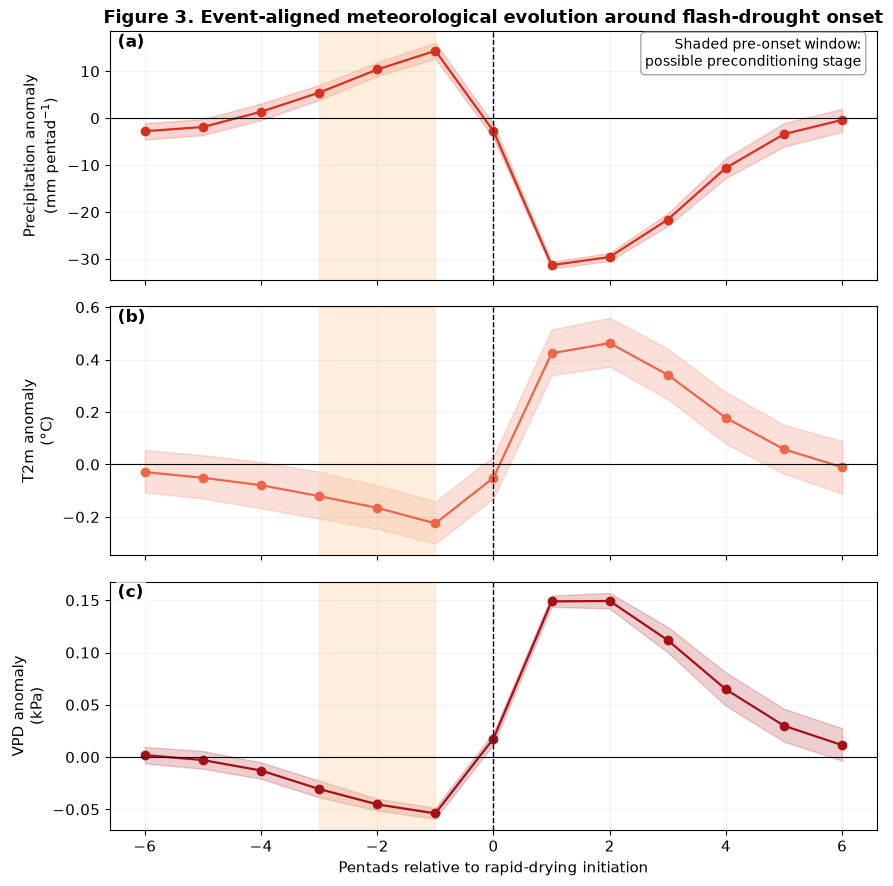

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

specs = [
    ("tp_anom_mm", "Precipitation anomaly\n(mm pentad$^{-1}$)", "#d7301f"),
    ("t2m_anom_c", "T2m anomaly\n(°C)", "#ef6548"),
    ("vpd_anom_kpa", "VPD anomaly\n(kPa)", "#a50f15"),
]

for i, (ax, (var, ylabel, color)) in enumerate(zip(axes, specs)):
    sub = lag[lag["variable"] == var].sort_values("lag")
    ax.plot(sub["lag"], sub["mean"], marker="o", linewidth=1.6, color=color)
    ax.fill_between(sub["lag"], sub["ci95_low"], sub["ci95_high"], color=color, alpha=0.20)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axvline(0, color="black", linestyle="--", linewidth=1.0)
    ax.axvspan(-3, -1, color="#fdd0a2", alpha=0.35)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.15)
    add_panel_label(ax, f"({chr(97+i)})")

axes[0].set_title("Figure 3. Event-aligned meteorological evolution around flash-drought onset")
axes[-1].set_xlabel("Pentads relative to rapid-drying initiation")
add_note_box(
    axes[0],
    "Shaded pre-onset window:\npossible preconditioning stage",
    loc="upper right"
)

fig.tight_layout()
safe_savefig(fig, OUT / "Figure3_driver_evolution_warm.png", dpi=FIG_DPI)
plt.show()


# Figure 4 — Robustness / sensitivity summary
Agar mudah dijelaskan: jumlah event + ukuran konsistensi terhadap benchmark.


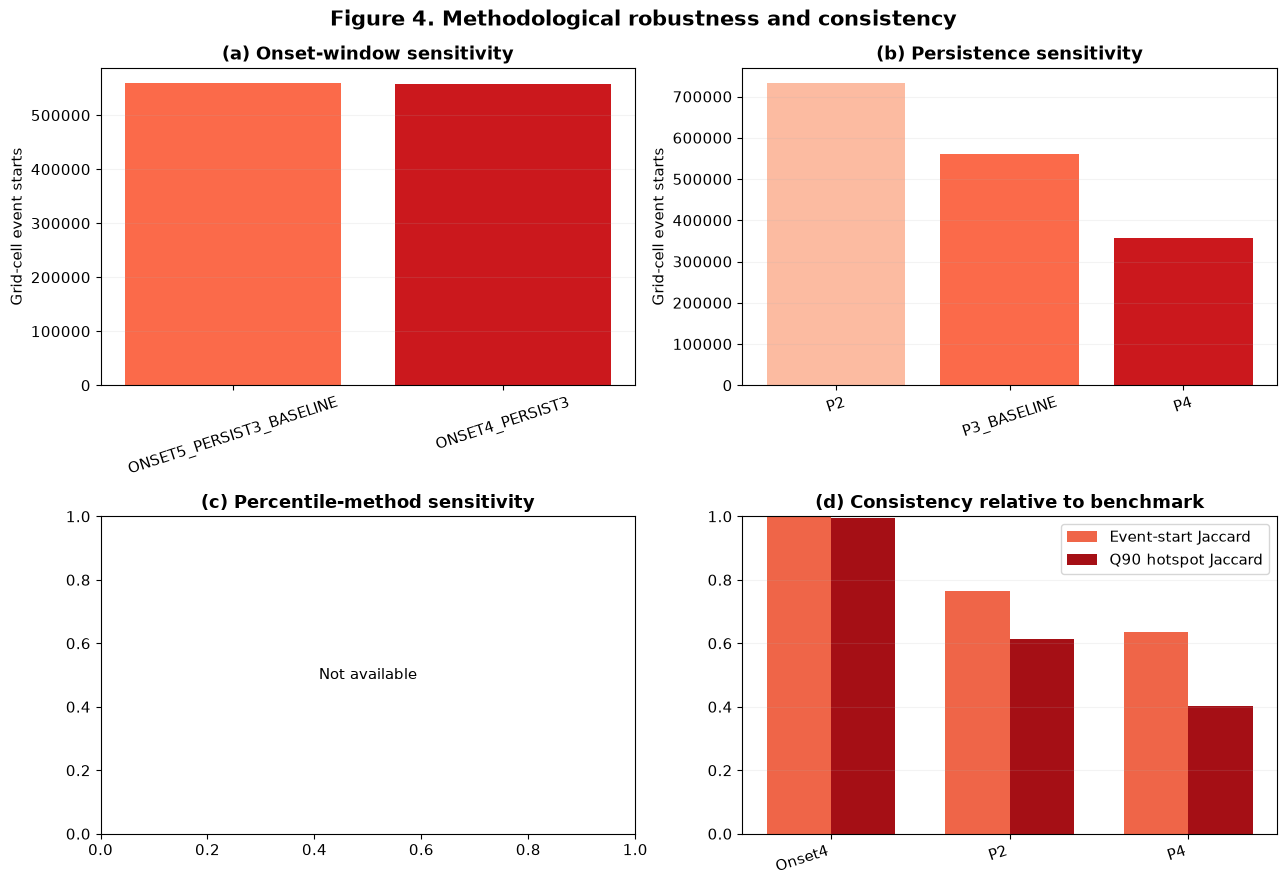

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (a) Onset sensitivity
if onset_summary is not None:
    axes[0,0].bar(onset_summary["method"], onset_summary["gridcell_event_starts_1996_2024"], color=["#fb6a4a", "#cb181d"])
    axes[0,0].set_title("(a) Onset-window sensitivity")
    axes[0,0].set_ylabel("Grid-cell event starts")
    axes[0,0].tick_params(axis="x", rotation=18)
    axes[0,0].grid(axis="y", alpha=0.15)
else:
    axes[0,0].text(0.5, 0.5, "Not available", ha="center", va="center")
    axes[0,0].set_title("(a) Onset-window sensitivity")

# (b) Persistence sensitivity
if persist_summary is not None:
    cols = ["#fcbba1", "#fb6a4a", "#cb181d"][:len(persist_summary)]
    axes[0,1].bar(persist_summary["method"], persist_summary["gridcell_event_starts_1996_2024"], color=cols)
    axes[0,1].set_title("(b) Persistence sensitivity")
    axes[0,1].set_ylabel("Grid-cell event starts")
    axes[0,1].tick_params(axis="x", rotation=18)
    axes[0,1].grid(axis="y", alpha=0.15)
else:
    axes[0,1].text(0.5, 0.5, "Not available", ha="center", va="center")
    axes[0,1].set_title("(b) Persistence sensitivity")

# (c) Percentile-method sensitivity
if pct_summary is not None:
    cols = ["#fdd0a2", "#fd8d3c", "#bd0026"][:len(pct_summary)]
    axes[1,0].bar(pct_summary["method"], pct_summary["gridcell_event_starts_1996_2024"], color=cols)
    axes[1,0].set_title("(c) Percentile-method sensitivity")
    axes[1,0].set_ylabel("Grid-cell event starts")
    axes[1,0].tick_params(axis="x", rotation=18)
    axes[1,0].grid(axis="y", alpha=0.15)
else:
    axes[1,0].text(0.5, 0.5, "Not available", ha="center", va="center")
    axes[1,0].set_title("(c) Percentile-method sensitivity")

# (d) Consistency metrics
consistency_rows = []
if onset_consist is not None:
    rr = onset_consist.iloc[0]
    consistency_rows.append(("Onset4", rr["event_start_jaccard"], rr["q90_hotspot_jaccard"]))
if persist_consist is not None:
    for _, rr in persist_consist.iterrows():
        consistency_rows.append((rr["variant"], rr["event_start_jaccard"], rr["q90_hotspot_jaccard"]))
if pct_consist is not None:
    for _, rr in pct_consist.iterrows():
        consistency_rows.append((rr["variant"], rr["event_start_jaccard"], rr["q90_hotspot_jaccard"]))

if len(consistency_rows) > 0:
    cdf = pd.DataFrame(consistency_rows, columns=["variant", "event_start_jaccard", "hotspot_q90_jaccard"])
    x = np.arange(len(cdf))
    width = 0.36
    axes[1,1].bar(x - width/2, cdf["event_start_jaccard"], width=width, color="#ef6548", label="Event-start Jaccard")
    axes[1,1].bar(x + width/2, cdf["hotspot_q90_jaccard"], width=width, color="#a50f15", label="Q90 hotspot Jaccard")
    axes[1,1].set_xticks(x)
    axes[1,1].set_xticklabels(cdf["variant"], rotation=18, ha="right")
    axes[1,1].set_ylim(0, 1)
    axes[1,1].set_title("(d) Consistency relative to benchmark")
    axes[1,1].grid(axis="y", alpha=0.15)
    axes[1,1].legend()
else:
    axes[1,1].text(0.5, 0.5, "Not available", ha="center", va="center")
    axes[1,1].set_title("(d) Consistency relative to benchmark")

fig.suptitle("Figure 4. Methodological robustness and consistency", fontsize=15, fontweight="bold")
fig.tight_layout()
safe_savefig(fig, OUT / "Figure4_robustness_summary_warm.png", dpi=FIG_DPI)
plt.show()


# Figure 5 — Representative flash-drought evolution for the four highest-ranked years

Figure ini sekarang **tidak lagi hanya 2015**.

Empat panel dibuat untuk **2003, 1997, 2015, dan 2004**. Untuk setiap tahun, notebook memilih satu grid-event secara objektif, yaitu event dengan `severity_p40_at_start` tertinggi pada tahun tersebut.

Setiap panel memperlihatkan RZSM percentile, threshold P40/P20, rapid-onset stage, drought-core/recovery stage, total event period, onset time, onset speed, duration, severity, dan minimum percentile.


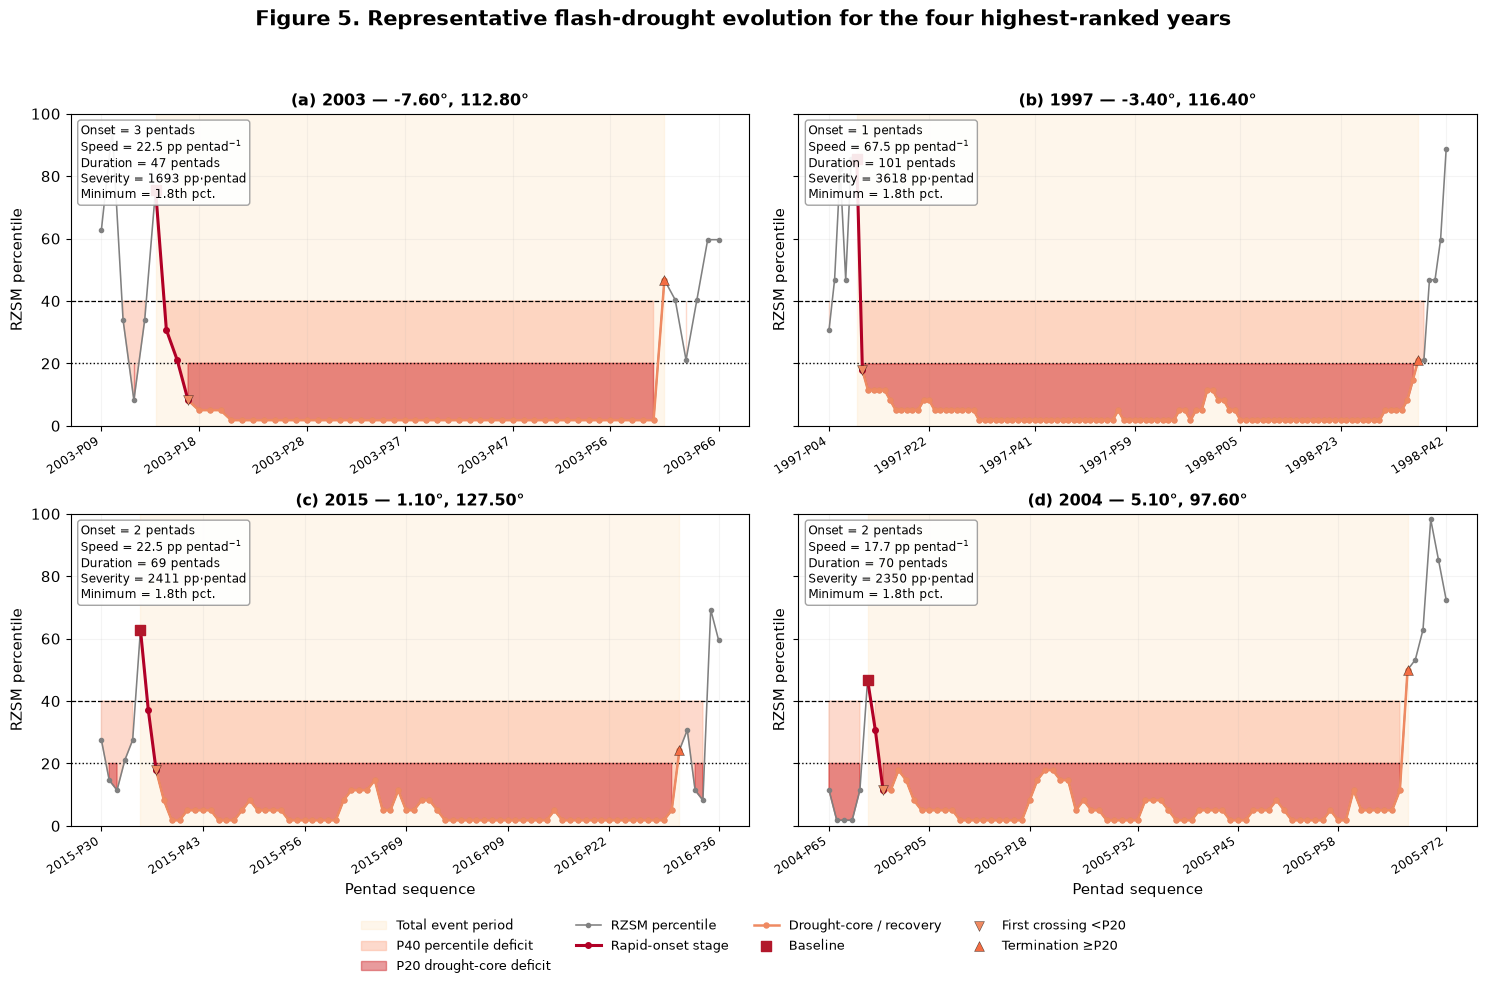

,year,latitude,longitude,onset_time,onset_speed,duration,severity,minimum_percentile
0,2003,-7.6,112.8,3,22.493574,47,1692.956299,1.799486
1,1997,-3.4,116.4,1,67.480721,101,3617.609375,1.799486
2,2015,1.1,127.5,2,22.493572,69,2411.259521,1.799486
3,2004,5.1,97.6,2,17.673523,70,2349.845703,1.799486


In [8]:
# ---------------------------------------------------------
# Build percentile series in year-major order to match
# the detection time_index.
# ---------------------------------------------------------
pct_time = (
    pct.transpose(
        "year",
        "pentad",
        "latitude",
        "longitude",
    )
    .stack(time_index=("year", "pentad"))
    .reset_index("time_index", drop=True)
    .assign_coords(
        time_index=np.arange(
            pct.sizes["year"] * pct.sizes["pentad"]
        )
    )
)

full_labels = build_full_time_labels(det)


def plot_representative_event(ax, year_choice, panel_label):
    rep = auto_select_representative_event(det, int(year_choice))

    rep_lat = float(rep["latitude"])
    rep_lon = float(rep["longitude"])
    rep_ti = int(rep["time_index"])

    pct_series = pct_time.sel(
        latitude=rep_lat,
        longitude=rep_lon,
        method="nearest",
    )

    det_series = det.sel(
        latitude=rep_lat,
        longitude=rep_lon,
        method="nearest",
    )

    baseline_p = float(
        pct_series.isel(time_index=rep_ti).values
    )
    onset_time = int(
        det_series["onset_time_pentads_at_start"]
        .sel(time_index=rep_ti)
        .values
    )
    duration = int(
        det_series["duration_pentads_at_start"]
        .sel(time_index=rep_ti)
        .values
    )
    onset_speed = float(
        det_series["onset_speed_at_start"]
        .sel(time_index=rep_ti)
        .values
    )
    severity = float(
        det_series["severity_p40_at_start"]
        .sel(time_index=rep_ti)
        .values
    )
    minimum = float(
        det_series["minimum_percentile_at_start"]
        .sel(time_index=rep_ti)
        .values
    )

    cross_idx = rep_ti + onset_time
    term_idx = rep_ti + duration

    left = max(0, rep_ti - 5)
    right = min(
        pct_series.sizes["time_index"],
        term_idx + 6,
    )

    x = np.arange(left, right)
    y = pct_series.isel(
        time_index=slice(left, right)
    ).values
    labels = full_labels[left:right]

    # Warm paper-style shading
    ax.axvspan(
        rep_ti,
        term_idx,
        color="#fee8c8",
        alpha=0.36,
        label="Total event period",
        zorder=0,
    )

    ax.fill_between(
        x,
        40,
        y,
        where=(y < 40),
        color="#fcae91",
        alpha=0.46,
        label="P40 percentile deficit",
        zorder=1,
    )

    ax.fill_between(
        x,
        20,
        y,
        where=(y < 20),
        color="#cb181d",
        alpha=0.43,
        label="P20 drought-core deficit",
        zorder=2,
    )

    ax.plot(
        x,
        y,
        color="0.50",
        marker="o",
        markersize=3.0,
        linewidth=1.15,
        label="RZSM percentile",
        zorder=3,
    )

    onset_x = np.arange(rep_ti, cross_idx + 1)
    onset_y = pct_series.isel(
        time_index=slice(rep_ti, cross_idx + 1)
    ).values

    ax.plot(
        onset_x,
        onset_y,
        color="#b10026",
        marker="o",
        linewidth=2.2,
        markersize=4.0,
        label="Rapid-onset stage",
        zorder=5,
    )

    if cross_idx < term_idx:
        core_x = np.arange(cross_idx, term_idx + 1)
        core_y = pct_series.isel(
            time_index=slice(cross_idx, term_idx + 1)
        ).values
        ax.plot(
            core_x,
            core_y,
            color="#ef8a62",
            marker="o",
            linewidth=1.8,
            markersize=3.6,
            label="Drought-core / recovery",
            zorder=4,
        )

    ax.axhline(40, color="black", linestyle="--", linewidth=0.9)
    ax.axhline(20, color="black", linestyle=":", linewidth=1.0)

    ax.scatter(
        [rep_ti],
        [baseline_p],
        marker="s",
        s=42,
        color="#b2182b",
        zorder=7,
        label="Baseline",
    )

    ax.scatter(
        [cross_idx],
        [float(pct_series.isel(time_index=cross_idx).values)],
        marker="v",
        s=50,
        color="#ef8a62",
        edgecolor="black",
        linewidth=0.25,
        zorder=7,
        label="First crossing <P20",
    )

    ax.scatter(
        [term_idx],
        [float(pct_series.isel(time_index=term_idx).values)],
        marker="^",
        s=50,
        color="#f46d43",
        edgecolor="black",
        linewidth=0.25,
        zorder=7,
        label="Termination ≥P20",
    )

    ax.set_ylim(0, 100)
    ax.set_title(
        f"({panel_label}) {year_choice} — "
        f"{rep_lat:.2f}°, {rep_lon:.2f}°",
        fontsize=11.5,
        fontweight="bold",
    )
    ax.set_ylabel("RZSM percentile")

    nshow = min(7, len(x))
    tick_idx = np.linspace(
        0,
        len(x) - 1,
        nshow,
        dtype=int,
    )
    ax.set_xticks(x[tick_idx])
    ax.set_xticklabels(
        [labels[i] for i in tick_idx],
        rotation=32,
        ha="right",
        fontsize=8.5,
    )
    ax.grid(alpha=0.13)

    info = (
        f"Onset = {onset_time} pentads\n"
        f"Speed = {onset_speed:.1f} pp pentad$^{{-1}}$\n"
        f"Duration = {duration} pentads\n"
        f"Severity = {severity:.0f} pp·pentad\n"
        f"Minimum = {minimum:.1f}th pct."
    )

    ax.text(
        0.015,
        0.97,
        info,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=8.7,
        bbox=dict(
            facecolor="white",
            edgecolor="0.6",
            alpha=0.90,
            boxstyle="round,pad=0.25",
        ),
        zorder=10,
    )

    return {
        "year": int(year_choice),
        "latitude": rep_lat,
        "longitude": rep_lon,
        "onset_time": onset_time,
        "onset_speed": onset_speed,
        "duration": duration,
        "severity": severity,
        "minimum_percentile": minimum,
    }


fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 10),
    sharey=True,
)

representative_rows = []

for ax, yr, label in zip(
    axes.ravel(),
    REP_YEARS,
    ["a", "b", "c", "d"],
):
    representative_rows.append(
        plot_representative_event(
            ax,
            int(yr),
            label,
        )
    )

axes[1, 0].set_xlabel("Pentad sequence")
axes[1, 1].set_xlabel("Pentad sequence")

handles, labels = axes[0, 0].get_legend_handles_labels()
unique = {}
for h, lab in zip(handles, labels):
    if lab not in unique:
        unique[lab] = h

fig.legend(
    unique.values(),
    unique.keys(),
    loc="lower center",
    bbox_to_anchor=(0.5, 0.005),
    ncol=4,
    frameon=False,
    fontsize=9,
)

fig.suptitle(
    "Figure 5. Representative flash-drought evolution "
    "for the four highest-ranked years",
    fontsize=15,
    fontweight="bold",
)

fig.tight_layout(rect=[0, 0.075, 1, 0.95])

safe_savefig(
    fig,
    OUT / "Figure5_representative_top4_years_warm.png",
    dpi=FIG_DPI,
)

plt.show()

representative_table = pd.DataFrame(representative_rows)
representative_table.to_csv(
    OUT / "Figure5_representative_top4_event_metadata.csv",
    index=False,
)

display(representative_table)


# Figure 6 — Selected-year first-onset map

Peta ini memperlihatkan **pentad onset pertama** untuk `CASE_YEAR` (default = 2003), dibagi menjadi empat panel regional agar pola spasial lebih mudah dibaca.

**Compatibility fix:** versi ini memakai `mpl.colormaps["YlOrRd"].resampled(...)`, bukan `matplotlib.cm.get_cmap(...)`, sehingga kompatibel dengan Matplotlib baru.


C:\Users\User\AppData\Local\Temp\ipykernel_17332\2404283877.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.11, 1, 0.96])
c:\Users\User\anaconda3\envs\era5\Lib\site-packages\cartopy\mpl\ticker.py:151: MatplotlibDeprecationWarning: The locs attribute was deprecated in Matplotlib 3.11 and will be removed in 3.13.
  self.locs, degs, mins, secs = self._get_dms(self.locs)
c:\Users\User\anaconda3\envs\era5\Lib\site-packages\cartopy\mpl\ticker.py:151: MatplotlibDeprecationWarning: The locs attribute was deprecated in Matplotlib 3.11 and will be removed in 3.13.
  self.locs, degs, mins, secs = self._get_dms(self.locs)
c:\Users\User\anaconda3\envs\era5\Lib\site-packages\cartopy\mpl\ticker.py:151: MatplotlibDeprecationWarning: The locs attribute was deprecated in Matplotlib 3.11 and will be removed in 3.13.
  self.locs, degs, mins, secs = self._get_dms(self.locs)
c:\Users\User\anaconda3\envs\era

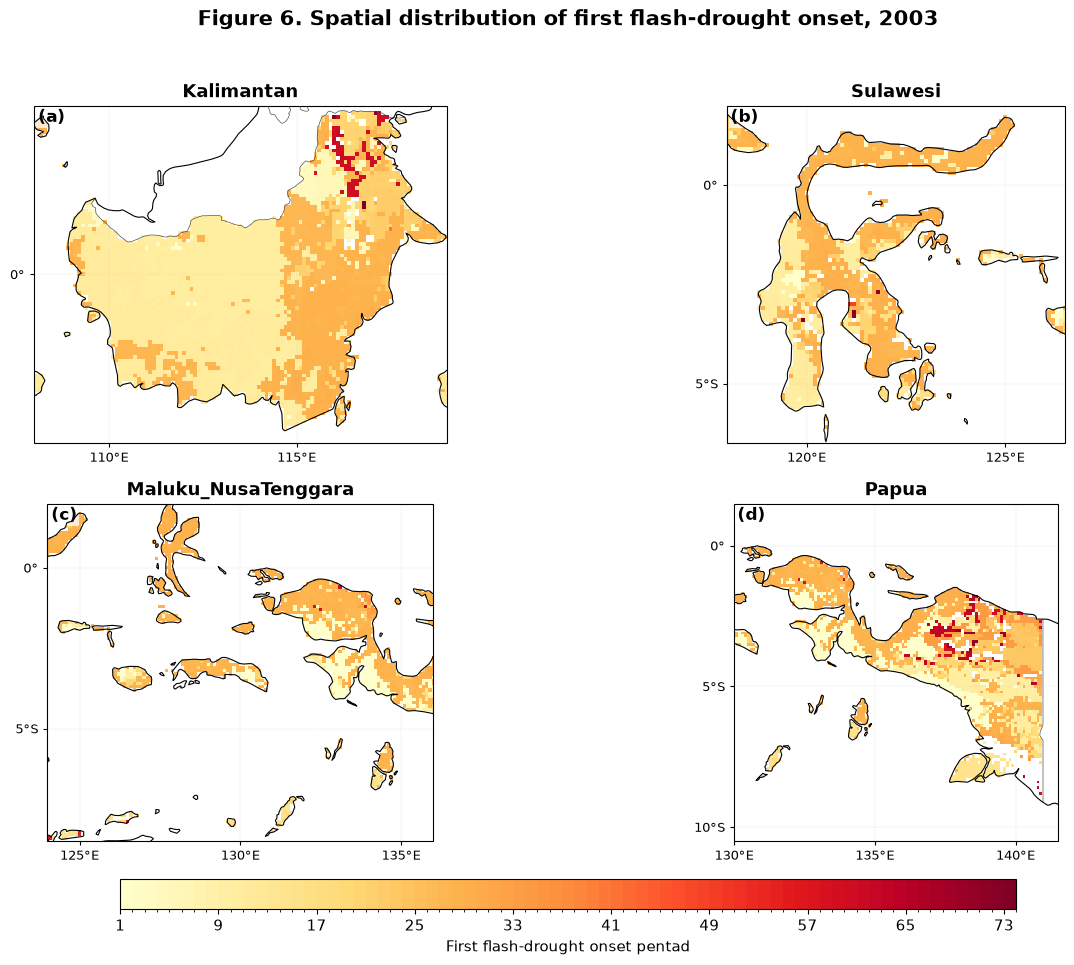

In [9]:
d_case = det.where(det["year"] == CASE_YEAR, drop=True)
start_case = (d_case["fd_event_start"] == 1)

first_onset = d_case["pentad"].where(start_case).min("time_index")
finite_vals = first_onset.values[np.isfinite(first_onset.values)]

if finite_vals.size == 0:
    raise ValueError(f"No onset found for CASE_YEAR={CASE_YEAR}.")

pmin = int(np.nanmin(finite_vals))
pmax = int(np.nanmax(finite_vals))
bounds = np.arange(pmin, pmax + 2)
cmap_disc = mpl.colormaps["YlOrRd"].resampled(len(bounds) - 1)
norm_disc = BoundaryNorm(bounds, cmap_disc.N)

fig = plt.figure(figsize=(14, 10))
positions = [221, 222, 223, 224]

for pos, (name, ext) in zip(positions, SUBREGIONS.items()):
    ax = make_geo_ax(fig, pos, ext)
    im = pmesh_map(
        ax,
        first_onset,
        CMAP_WARM,
        name,
        "First onset pentad",
        discrete={"cmap": cmap_disc, "norm": norm_disc},
    )
    add_panel_label(ax, f"({chr(96 + positions.index(pos) + 1)})")

cax = fig.add_axes([0.18, 0.08, 0.64, 0.03])
cb = mpl.colorbar.ColorbarBase(cax, cmap=cmap_disc, norm=norm_disc, boundaries=bounds, orientation="horizontal")
cb.set_label("First flash-drought onset pentad")

fig.suptitle(f"Figure 6. Spatial distribution of first flash-drought onset, {CASE_YEAR}", fontsize=15, fontweight="bold")
plt.tight_layout(rect=[0, 0.11, 1, 0.96])
safe_savefig(fig, OUT / f"Figure6_first_onset_map_{CASE_YEAR}_warm.png", dpi=FIG_DPI)
plt.show()


# Figure 7 — Active FD type map
Peta ini memisahkan:
- **New-onset FD**
- **Ongoing FD intensification / drought-core phase**

Saya buat warnanya tetap hangat: merah tua dan oranye.


c:\Users\User\anaconda3\envs\era5\Lib\site-packages\cartopy\mpl\ticker.py:151: MatplotlibDeprecationWarning: The locs attribute was deprecated in Matplotlib 3.11 and will be removed in 3.13.
  self.locs, degs, mins, secs = self._get_dms(self.locs)
c:\Users\User\anaconda3\envs\era5\Lib\site-packages\cartopy\mpl\ticker.py:151: MatplotlibDeprecationWarning: The locs attribute was deprecated in Matplotlib 3.11 and will be removed in 3.13.
  self.locs, degs, mins, secs = self._get_dms(self.locs)
c:\Users\User\anaconda3\envs\era5\Lib\site-packages\cartopy\mpl\ticker.py:151: MatplotlibDeprecationWarning: The locs attribute was deprecated in Matplotlib 3.11 and will be removed in 3.13.
  self.locs, degs, mins, secs = self._get_dms(self.locs)
c:\Users\User\anaconda3\envs\era5\Lib\site-packages\cartopy\mpl\ticker.py:151: MatplotlibDeprecationWarning: The locs attribute was deprecated in Matplotlib 3.11 and will be removed in 3.13.
  self.locs, degs, mins, secs = self._get_dms(self.locs)
c:\Users

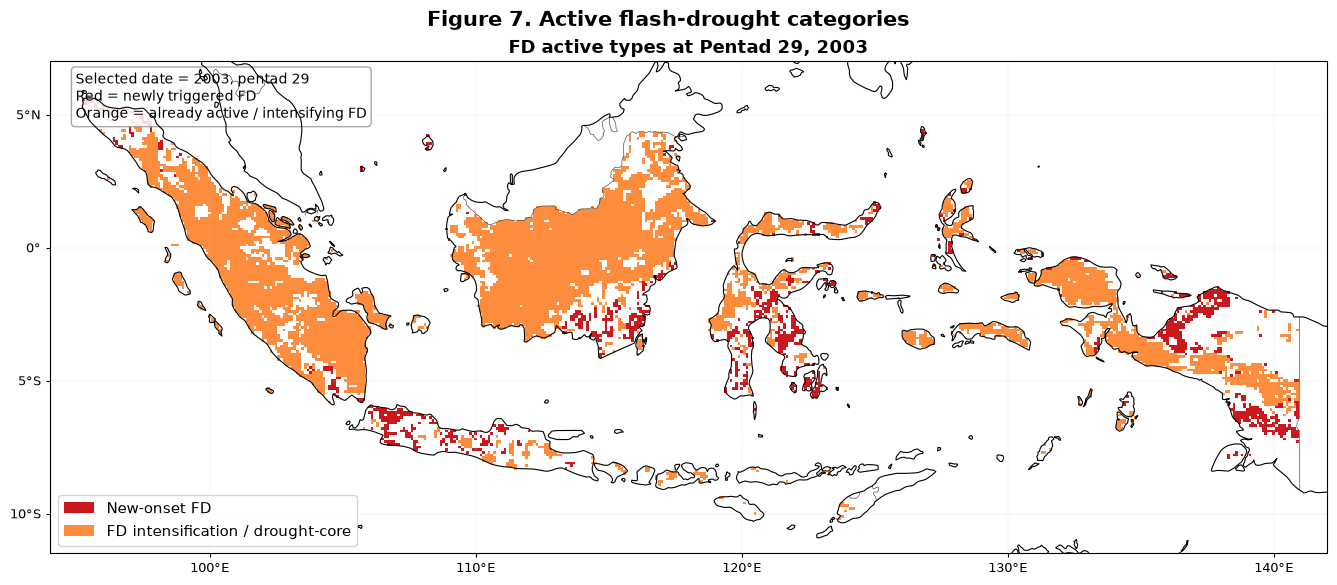

In [10]:
d_active = det.where(det["year"] == ACTIVE_YEAR, drop=True)
new_onset = (d_active["fd_event_start"] == 1).where(d_active["pentad"] == ACTIVE_PENTAD, False).max("time_index")
ongoing = (d_active["fd_drought_core"] == 1).where(d_active["pentad"] == ACTIVE_PENTAD, False).max("time_index")

category = xr.full_like(new_onset.astype(float), np.nan)
category = xr.where(new_onset, 1, category)
category = xr.where((~new_onset) & ongoing, 2, category)

cat_cmap = ListedColormap(["#cb181d", "#fd8d3c"])
cat_norm = BoundaryNorm([0.5, 1.5, 2.5], cat_cmap.N)

fig = plt.figure(figsize=(13.5, 5.8))
ax = make_geo_ax(fig, 111, INDO_EXTENT)
im = pmesh_map(
    ax, category, None,
    f"FD active types at Pentad {ACTIVE_PENTAD}, {ACTIVE_YEAR}",
    "Category",
    discrete={"cmap": cat_cmap, "norm": cat_norm}
)

legend_handles = [
    Patch(facecolor="#cb181d", edgecolor="none", label="New-onset FD"),
    Patch(facecolor="#fd8d3c", edgecolor="none", label="FD intensification / drought-core"),
]
ax.legend(handles=legend_handles, loc="lower left", frameon=True)
add_note_box(
    ax,
    f"Selected date = {ACTIVE_YEAR}, pentad {ACTIVE_PENTAD}\n"
    "Red = newly triggered FD\n"
    "Orange = already active / intensifying FD",
    loc="upper left"
)

fig.suptitle("Figure 7. Active flash-drought categories", fontsize=15, fontweight="bold")
fig.tight_layout()
safe_savefig(fig, OUT / f"Figure7_active_fd_types_{ACTIVE_YEAR}_P{ACTIVE_PENTAD:02d}_warm.png", dpi=FIG_DPI)
plt.show()


# Figure S1 — Hotspot masks


c:\Users\User\anaconda3\envs\era5\Lib\site-packages\cartopy\mpl\ticker.py:151: MatplotlibDeprecationWarning: The locs attribute was deprecated in Matplotlib 3.11 and will be removed in 3.13.
  self.locs, degs, mins, secs = self._get_dms(self.locs)
c:\Users\User\anaconda3\envs\era5\Lib\site-packages\cartopy\mpl\ticker.py:151: MatplotlibDeprecationWarning: The locs attribute was deprecated in Matplotlib 3.11 and will be removed in 3.13.
  self.locs, degs, mins, secs = self._get_dms(self.locs)
c:\Users\User\anaconda3\envs\era5\Lib\site-packages\cartopy\mpl\ticker.py:151: MatplotlibDeprecationWarning: The locs attribute was deprecated in Matplotlib 3.11 and will be removed in 3.13.
  self.locs, degs, mins, secs = self._get_dms(self.locs)
c:\Users\User\anaconda3\envs\era5\Lib\site-packages\cartopy\mpl\ticker.py:151: MatplotlibDeprecationWarning: The locs attribute was deprecated in Matplotlib 3.11 and will be removed in 3.13.
  self.locs, degs, mins, secs = self._get_dms(self.locs)
c:\Users

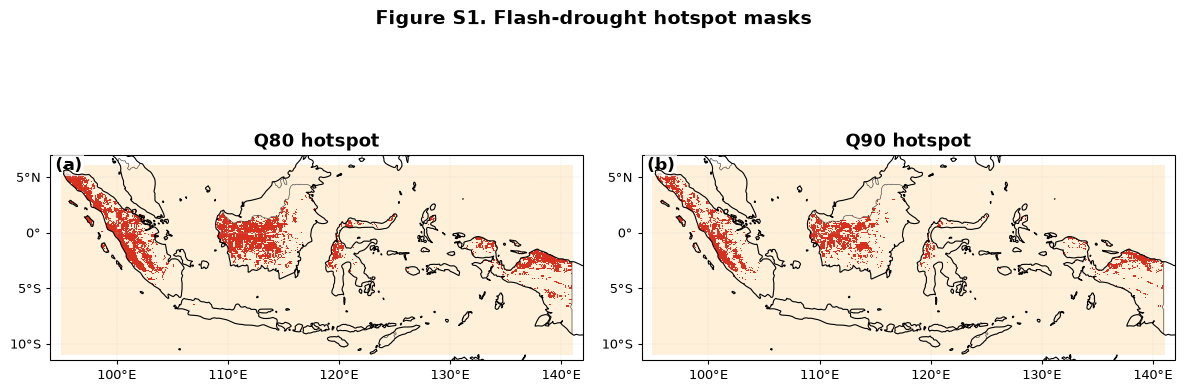

In [11]:
fig = plt.figure(figsize=(12, 4.8))

for pos, var, ttl, lab in [
    (121, "hotspot_q80", "Q80 hotspot", "a"),
    (122, "hotspot_q90", "Q90 hotspot", "b"),
]:
    ax = make_geo_ax(fig, pos, INDO_EXTENT)
    cmap_hot = ListedColormap(["#fef0d9", "#d7301f"])
    norm_hot = BoundaryNorm([-0.5, 0.5, 1.5], cmap_hot.N)
    im = pmesh_map(ax, hot[var], None, ttl, "mask", discrete={"cmap": cmap_hot, "norm": norm_hot})
    add_panel_label(ax, f"({lab})")

fig.suptitle("Figure S1. Flash-drought hotspot masks", fontsize=14, fontweight="bold")
fig.tight_layout()
safe_savefig(fig, OUT / "FigureS1_hotspot_masks_warm.png", dpi=FIG_DPI)
plt.show()


# Caption helper text
Cell ini mencetak ringkasan angka penting agar mudah dipakai untuk caption atau narasi bab hasil.


In [12]:
p0 = metric_lag("tp_anom_mm", 0)
p1 = metric_lag("tp_anom_mm", 1)
t1 = metric_lag("t2m_anom_c", 1)
v1 = metric_lag("vpd_anom_kpa", 1)

fp = metric_phase("strong_precip_deficit_fraction")
fv = metric_phase("high_vpd_fraction")
fc = metric_phase("compound_pdef_highvpd_fraction")
fe = metric_phase("either_pdef_or_highvpd_fraction")

print("SUGGESTED RESULT NOTES")
print("----------------------")
print(
    f"At FD initiation (lag 0), precipitation anomaly is {p0['mean']:.2f} mm pentad-1 "
    f"(95% CI {p0['ci95_low']:.2f} to {p0['ci95_high']:.2f})."
)
print(
    f"One pentad after initiation, T2m anomaly is {t1['mean']:+.3f} °C and "
    f"VPD anomaly is {v1['mean']:+.3f} kPa."
)
print(
    f"During rapid development, strong precipitation deficit occurs over "
    f"{fp[0]*100:.1f}% of area-time samples, high VPD over {fv[0]*100:.1f}%, "
    f"and compound P-deficit + high-VPD over {fc[0]*100:.1f}%."
)
print(
    f"At least one of the two stressors (strong P-deficit or high VPD) occurs in "
    f"{fe[0]*100:.1f}% of area-time samples."
)


SUGGESTED RESULT NOTES
----------------------
At FD initiation (lag 0), precipitation anomaly is -2.75 mm pentad-1 (95% CI -4.21 to -1.23).
One pentad after initiation, T2m anomaly is +0.424 °C and VPD anomaly is +0.149 kPa.
During rapid development, strong precipitation deficit occurs over 47.9% of area-time samples, high VPD over 46.8%, and compound P-deficit + high-VPD over 37.0%.
At least one of the two stressors (strong P-deficit or high VPD) occurs in 57.7% of area-time samples.


In [13]:
manifest = {
    "purpose": "paper-style visual synthesis with warmer colors and clearer map styling",
    "main_outputs": [
        "Figure1_climatology_overview_warm.png",
        "Figure2_seasonality_interannual_warm.png",
        "Figure3_driver_evolution_warm.png",
        "Figure4_robustness_summary_warm.png",
        "Figure5_representative_top4_years_warm.png",
        f"Figure6_first_onset_map_{CASE_YEAR}_warm.png",
        f"Figure7_active_fd_types_{ACTIVE_YEAR}_P{ACTIVE_PENTAD:02d}_warm.png",
        "FigureS1_hotspot_masks_warm.png",
    ],
    "recommended_mapping_backend": "cartopy",
    "source_files": {
        "climatology": str(CLIM_NC),
        "hotspots": str(HOTSPOT_NC),
        "drivers_lag": str(LAG_CSV),
        "drivers_phase": str(PHASE_CSV),
        "detection": str(DETECTION_FILE),
        "percentile": str(PERCENTILE_FILE),
    },
}
(OUT / "manifest_05b_paper_style_visuals.json").write_text(
    json.dumps(manifest, indent=2),
    encoding="utf-8"
)

clim.close()
hot.close()
det.close()

print("Notebook 05b ready. Output directory:", OUT)


Notebook 05b ready. Output directory: D:\ERA5_LAND\output_fd_05b_paper_style_visuals
